In [5]:
from google.colab import files
uploaded = files.upload()


Saving vic-lgovt-com-com-clue-floor-use-block-2011-na.json to vic-lgovt-com-com-clue-floor-use-block-2011-na (1).json


In [6]:
%%writefile rule_engine.py
import geopandas as gpd
import pandas as pd

# Geometry validity: 检查无效几何
def check_invalid_geometry(gdf):
    invalid = gdf[~gdf.is_valid]
    return {"rule": "Geometry validity", "category": "Geometry", "violations": len(invalid), "details": invalid}

#Geometry overlaps: 检查 block 是否重叠
def check_overlaps(gdf):
    sindex = gdf.sindex
    overlaps = []
    for idx1, row1 in gdf.iterrows():
        possible_matches = list(sindex.intersection(row1.geometry.bounds))
        for idx2 in possible_matches:
            if idx1 != idx2:
                if row1.geometry.intersects(gdf.iloc[idx2].geometry):
                    overlaps.append((idx1, idx2))
    return {"rule": "Geometry overlaps", "category": "Geometry", "violations": len(overlaps), "details": overlaps}

# Null values: 检查缺失值
def check_nulls(gdf):
    null_counts = gdf.isnull().sum()
    return {"rule": "Null values", "category": "Attribute", "violations": int(null_counts.sum()), "details": null_counts}

# Negative floor space: 检查 floor_space 是否为负
def check_negative_floor_space(gdf, col="floor_space"):
    if col not in gdf.columns:
        return {"rule": "Negative floor space", "category": "Attribute", "violations": 0, "details": None}
    negative = gdf[gdf[col] < 0]
    return {"rule": "Negative floor space", "category": "Attribute", "violations": len(negative), "details": negative}

# Total consistency: 分项总和 <= 总列
def check_total_consistency(gdf, total_col="total"):
    if total_col not in gdf.columns:
        return {"rule": "Total consistency", "category": "Attribute", "violations": 0, "details": None}
    component_cols = [c for c in gdf.columns if c not in ["geometry", total_col]]
    gdf["component_sum"] = gdf[component_cols].sum(axis=1, skipna=True)
    inconsistent = gdf[gdf["component_sum"] > gdf[total_col]]
    return {"rule": "Total consistency", "category": "Attribute", "violations": len(inconsistent), "details": inconsistent}

# CRS check: 检查是否定义坐标系
def check_crs(gdf):
    return {"rule": "CRS check", "category": "Spatial", "violations": int(gdf.crs is None), "details": gdf.crs}

# Conflict block uses: 检查一个 block 是否有过多用途
def check_conflict_blocks(gdf, block_col="block_id", use_col="space_use", threshold=3):
    if block_col not in gdf.columns or use_col not in gdf.columns:
        return {"rule": "Conflict block uses", "category": "Business", "violations": 0, "details": None}
    conflict_blocks = gdf.groupby(block_col)[use_col].nunique()
    conflict_blocks = conflict_blocks[conflict_blocks > threshold]
    return {"rule": "Conflict block uses", "category": "Business", "violations": len(conflict_blocks), "details": conflict_blocks}

# 运行所有规则并返回 DataFrame
def run_all_rules(gdf):
    rules = [
        check_invalid_geometry,
        check_overlaps,
        check_nulls,
        check_negative_floor_space,
        check_total_consistency,
        check_crs,
        check_conflict_blocks
    ]
    results = []
    for rule in rules:
        results.append(rule(gdf))
    return pd.DataFrame(results)

# Convert overlap index pairs into a human-readable DataFrame with block_id and space_use.
def inspect_overlaps(gdf, details):
    import pandas as pd

    if not details or len(details) == 0:
        return pd.DataFrame(columns=["row1", "row2", "block1_id", "block1_use", "block2_id", "block2_use"])

    overlap_df = pd.DataFrame(details, columns=["row1", "row2"])
    overlap_df["block1_id"] = gdf.loc[overlap_df["row1"], "block_id"].values
    overlap_df["block1_use"] = gdf.loc[overlap_df["row1"], "space_use"].values
    overlap_df["block2_id"] = gdf.loc[overlap_df["row2"], "block_id"].values
    overlap_df["block2_use"] = gdf.loc[overlap_df["row2"], "space_use"].values
    return overlap_df


import matplotlib.pyplot as plt
# Visualize missing values by usage type.

def visualize_nulls(null_details, top_n=10):
    # Keep only columns with missing values
    null_details = null_details[null_details > 0].sort_values(ascending=False)

    if len(null_details) == 0:
        print("No missing values found.")
        return

    # Select top N
    null_details = null_details.head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))
    null_details.plot(kind="bar", color="tomato", alpha=0.7)
    plt.title(f"Top {top_n} Usage Types with Most Missing Values")
    plt.ylabel("Number of NULLs")
    plt.xlabel("Usage Type")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()



Overwriting rule_engine.py


                   rule   category  violations  \
0     Geometry validity   Geometry           0   
1     Geometry overlaps   Geometry        3828   
2           Null values  Attribute        2138   
3  Negative floor space  Attribute           0   
4     Total consistency  Attribute           0   
5             CRS check    Spatial           0   
6   Conflict block uses   Business           0   

                                             details  
0  Empty GeoDataFrame
Columns: [id, block_id, cen...  
1  [(0, 544), (0, 384), (0, 408), (0, 277), (0, 4...  
2  id                                         0
b...  
3                                               None  
4                                               None  
5                                          EPSG:4283  
6                                               None  


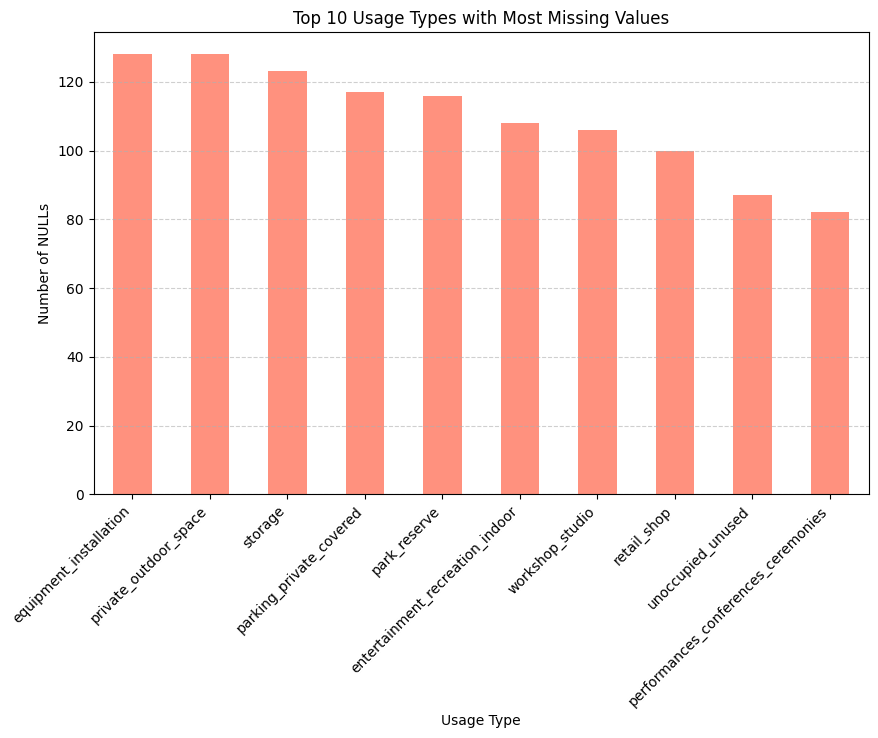

In [7]:
import importlib
import geopandas as gpd
import rule_engine

# 确保加载最新版本
importlib.reload(rule_engine)

# 读取数据
gdf = gpd.read_file("/content/vic-lgovt-com-com-clue-floor-use-block-2011-na.json")

# 跑规则
results = rule_engine.run_all_rules(gdf)
print(results)

# 提取 Null values 的 details 并可视化
null_details = results.loc[results["rule"]=="Null values", "details"].values[0]
rule_engine.visualize_nulls(null_details, top_n=10)

# 导出 Excel
results.to_excel("rule_check_results.xlsx", index=False)
